# 🧠 LLM Sampling Parameters: 6-Experiment Learning Path

**Goal**: Build deep intuition for temperature, top-p, top-k, and repetition penalty  
**Time**: ~45 minutes  
**Method**: Each experiment isolates ONE concept with visual proof

---

## How This Works

We simulate what happens inside an LLM's sampling head using synthetic logit distributions. This lets us isolate each parameter's effect without needing to call a real model API.

**Pipeline reminder:**
```
Raw Logits → [Temperature] → [Top-k] → [Top-p] → [Rep. Penalty] → Sample
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch, Rectangle
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# ─── Shared style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  '#c8c8e8',
    'text.color':       '#c8c8e8',
    'xtick.color':      '#888899',
    'ytick.color':      '#888899',
    'grid.color':       '#2a2a3e',
    'grid.linewidth':   0.5,
    'axes.grid':        True,
    'font.family':      'monospace',
})
ACCENT = ['#ff6b9d', '#c9e4ff', '#a8e6cf', '#ffd93d', '#ff9f43', '#a29bfe']
print('✅ Setup complete — all 6 notebooks ready to run')

✅ Setup complete — all 6 experiments ready to run


---
## 🔧 Core Utility Functions

These simulate the exact operations an LLM sampling head performs.

In [2]:
def softmax(logits):
    """Standard softmax: convert logits → probabilities."""
    e = np.exp(logits - np.max(logits))  # subtract max for numerical stability
    return e / e.sum()

def apply_temperature(logits, temperature):
    """Scale logits by temperature before softmax."""
    if temperature <= 0:
        raise ValueError('Temperature must be > 0')
    return logits / temperature

def apply_top_k(probs, k):
    """Zero out all tokens except the top-k, then renormalize."""
    if k <= 0 or k >= len(probs):
        return probs.copy()
    filtered = np.zeros_like(probs)
    top_indices = np.argsort(probs)[-k:]
    filtered[top_indices] = probs[top_indices]
    return filtered / filtered.sum()

def apply_top_p(probs, p):
    """Keep smallest set of tokens whose cumulative probability ≥ p."""
    sorted_idx = np.argsort(probs)[::-1]
    cumsum = np.cumsum(probs[sorted_idx])
    # Keep all tokens up to (and including) the one that crosses p
    cutoff = np.searchsorted(cumsum, p) + 1
    nucleus_idx = sorted_idx[:cutoff]
    filtered = np.zeros_like(probs)
    filtered[nucleus_idx] = probs[nucleus_idx]
    return filtered / filtered.sum(), cutoff

def apply_repetition_penalty(logits, penalty, generated_tokens):
    """Divide positive logits / multiply negative logits for seen tokens."""
    logits = logits.copy()
    for tok in generated_tokens:
        if logits[tok] > 0:
            logits[tok] /= penalty
        else:
            logits[tok] *= penalty
    return logits

# ── Synthetic logit generator ────────────────────────────────────────────────
def make_logits(n=20, seed=42, style='peaked'):
    rng = np.random.default_rng(seed)
    if style == 'peaked':
        logits = rng.normal(0, 1, n)
        logits[0] += 4   # one dominant token
    elif style == 'flat':
        logits = rng.normal(0, 0.3, n)
    elif style == 'bimodal':
        logits = rng.normal(0, 1, n)
        logits[0] += 3
        logits[5] += 2.5
    return logits

print('✅ Utility functions defined')

✅ Utility functions defined


---
# Experiment 1: Temperature Sweep 🌡️

**Question**: How does changing temperature reshape the probability distribution?

**Key formula**: `P(i) = softmax(logits / T)`

- `T < 1` → sharper (more confident)
- `T = 1` → unchanged
- `T > 1` → flatter (more random)

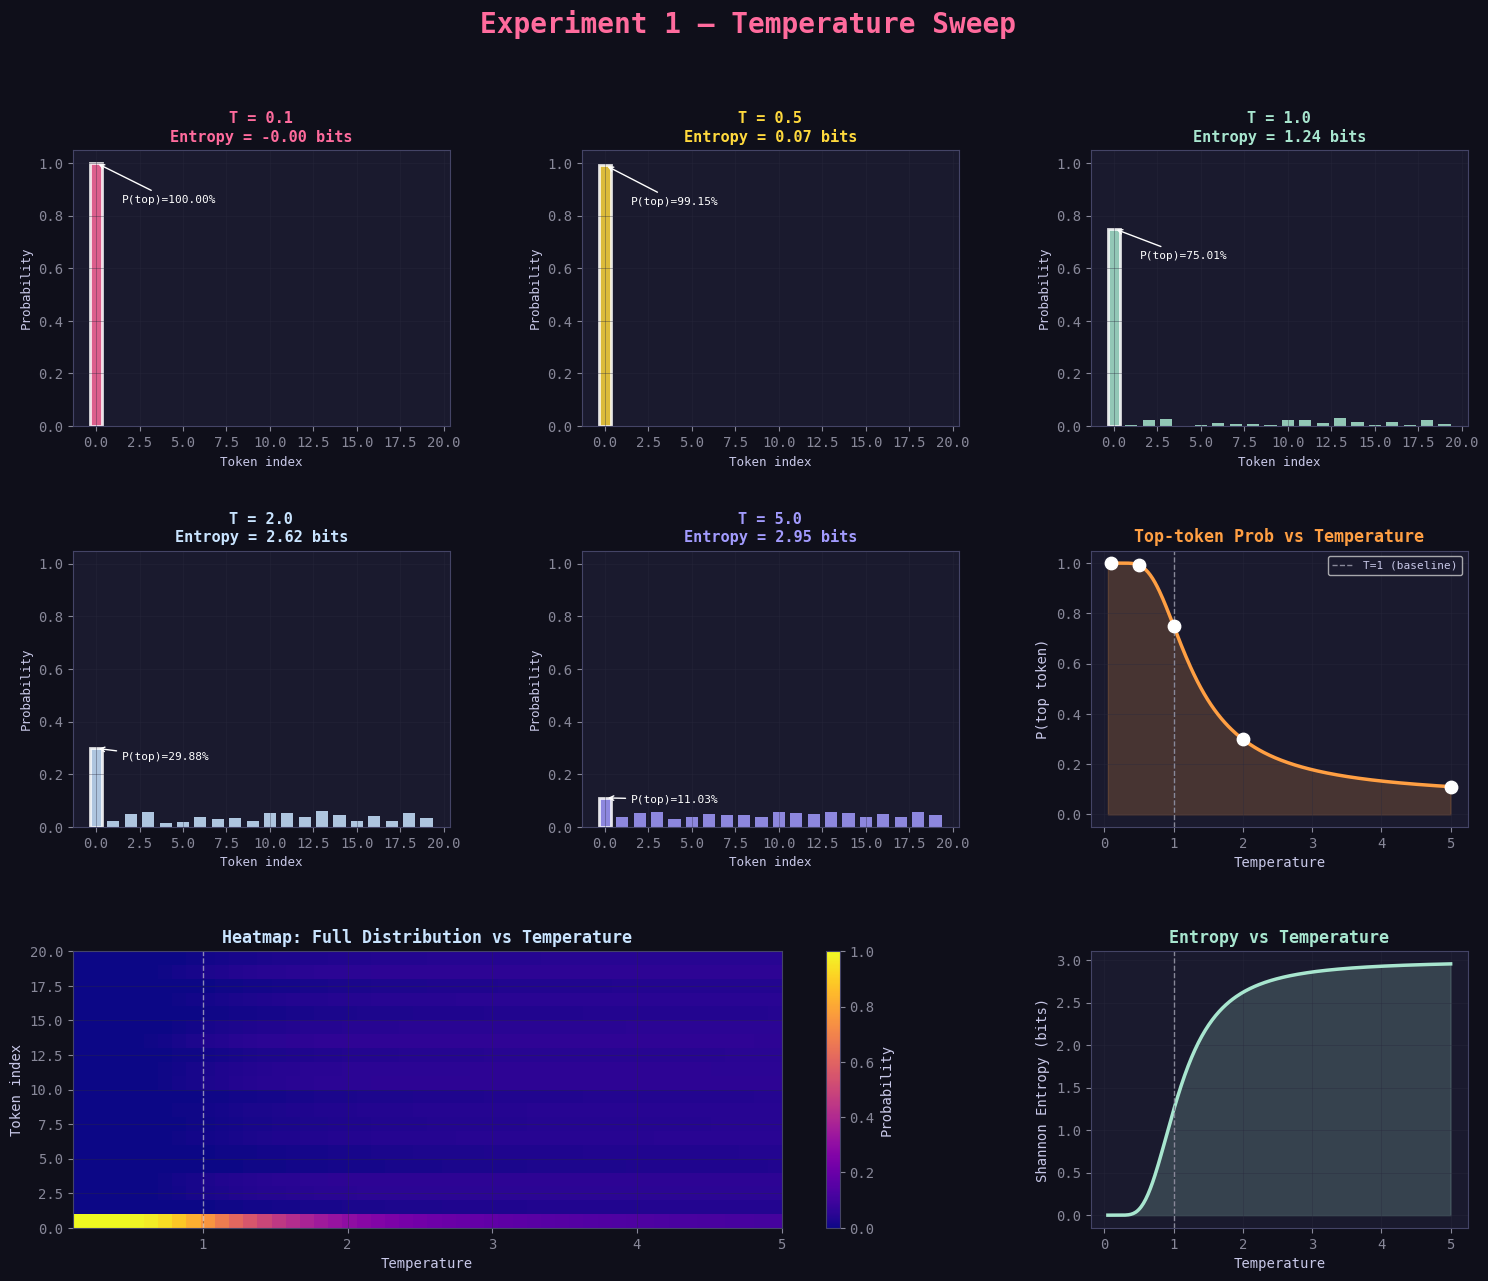

💾 Saved exp1_temperature.png


In [4]:
logits = make_logits(n=20, style='peaked')
temperatures = [0.1, 0.5, 1.0, 2.0, 5.0]
labels = [f'T = {t}' for t in temperatures]
token_labels = [f'T{i}' for i in range(len(logits))]

fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

fig.suptitle('Experiment 1 — Temperature Sweep', fontsize=20, fontweight='bold',
             color='#ff6b9d', y=0.98)

# ─── Panel A: Individual distributions ───────────────────────────────────────
colors = ['#ff6b9d', '#ffd93d', '#a8e6cf', '#c9e4ff', '#a29bfe']
for i, (T, col, lbl) in enumerate(zip(temperatures, colors, labels)):
    ax = fig.add_subplot(gs[i // 3, i % 3])
    probs = softmax(apply_temperature(logits, T))
    bars = ax.bar(range(len(probs)), probs, color=col, alpha=0.85, width=0.7, edgecolor='none')
    # Highlight top token
    top = np.argmax(probs)
    bars[top].set_edgecolor('white')
    bars[top].set_linewidth(2)
    entropy = -np.sum(probs * np.log(probs + 1e-12))
    ax.set_title(f'{lbl}\nEntropy = {entropy:.2f} bits', color=col, fontsize=11, fontweight='bold')
    ax.set_xlabel('Token index', fontsize=9)
    ax.set_ylabel('Probability', fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.annotate(f'P(top)={probs[top]:.2%}', xy=(top, probs[top]),
                xytext=(top + 1.5, probs[top] * 0.85),
                fontsize=8, color='white',
                arrowprops=dict(arrowstyle='->', color='white', lw=1))

# ─── Panel B: Top-token probability vs Temperature ────────────────────────────
ax_main = fig.add_subplot(gs[1, 2])
T_range = np.linspace(0.05, 5.0, 300)
top_probs = [softmax(apply_temperature(logits, T))[np.argmax(logits)] for T in T_range]
ax_main.plot(T_range, top_probs, color='#ff9f43', lw=2.5)
ax_main.fill_between(T_range, top_probs, alpha=0.2, color='#ff9f43')
for T in temperatures:
    p = softmax(apply_temperature(logits, T))[np.argmax(logits)]
    ax_main.scatter(T, p, s=80, zorder=5, color='white')
ax_main.axvline(1.0, color='#888899', lw=1, ls='--', label='T=1 (baseline)')
ax_main.set_xlabel('Temperature')
ax_main.set_ylabel('P(top token)')
ax_main.set_title('Top-token Prob vs Temperature', color='#ff9f43', fontweight='bold')
ax_main.legend(fontsize=8)

# ─── Panel C: Entropy vs Temperature ─────────────────────────────────────────
ax_ent = fig.add_subplot(gs[2, 2])
entropies = [-np.sum(softmax(apply_temperature(logits, T)) * 
             np.log(softmax(apply_temperature(logits, T)) + 1e-12)) for T in T_range]
ax_ent.plot(T_range, entropies, color='#a8e6cf', lw=2.5)
ax_ent.fill_between(T_range, entropies, alpha=0.2, color='#a8e6cf')
ax_ent.axvline(1.0, color='#888899', lw=1, ls='--')
ax_ent.set_xlabel('Temperature')
ax_ent.set_ylabel('Shannon Entropy (bits)')
ax_ent.set_title('Entropy vs Temperature', color='#a8e6cf', fontweight='bold')

# ─── Panel D: Heatmap of distribution evolution ───────────────────────────────
ax_heat = fig.add_subplot(gs[2, :2])
T_steps = np.linspace(0.1, 5.0, 50)
heat_data = np.array([softmax(apply_temperature(logits, T)) for T in T_steps])
im = ax_heat.imshow(heat_data.T, aspect='auto', cmap='plasma',
                    extent=[0.1, 5.0, 0, len(logits)], origin='lower')
plt.colorbar(im, ax=ax_heat, label='Probability')
ax_heat.set_xlabel('Temperature')
ax_heat.set_ylabel('Token index')
ax_heat.set_title('Heatmap: Full Distribution vs Temperature', 
                  color='#c9e4ff', fontweight='bold')
ax_heat.axvline(1.0, color='white', lw=1, ls='--', alpha=0.5)

plt.savefig('exp1_temperature.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('💾 Saved exp1_temperature.png')

### 🎯 Experiment 1 Takeaway

> **Temperature is a precision dial.** Low temperature → high confidence → deterministic output. High temperature → flat distribution → diverse, random output.
>
> **Rule of thumb**: Start at `T=0.7`. Decrease for factual tasks. Increase for creative tasks. Never use `T>2.0` in production.

---
# Experiment 2: Top-p (Nucleus Sampling) 🎯

**Question**: How does top-p restrict the candidate set, and why is it "dynamic"?

**Key insight**: The nucleus size *adapts* to the shape of the distribution.

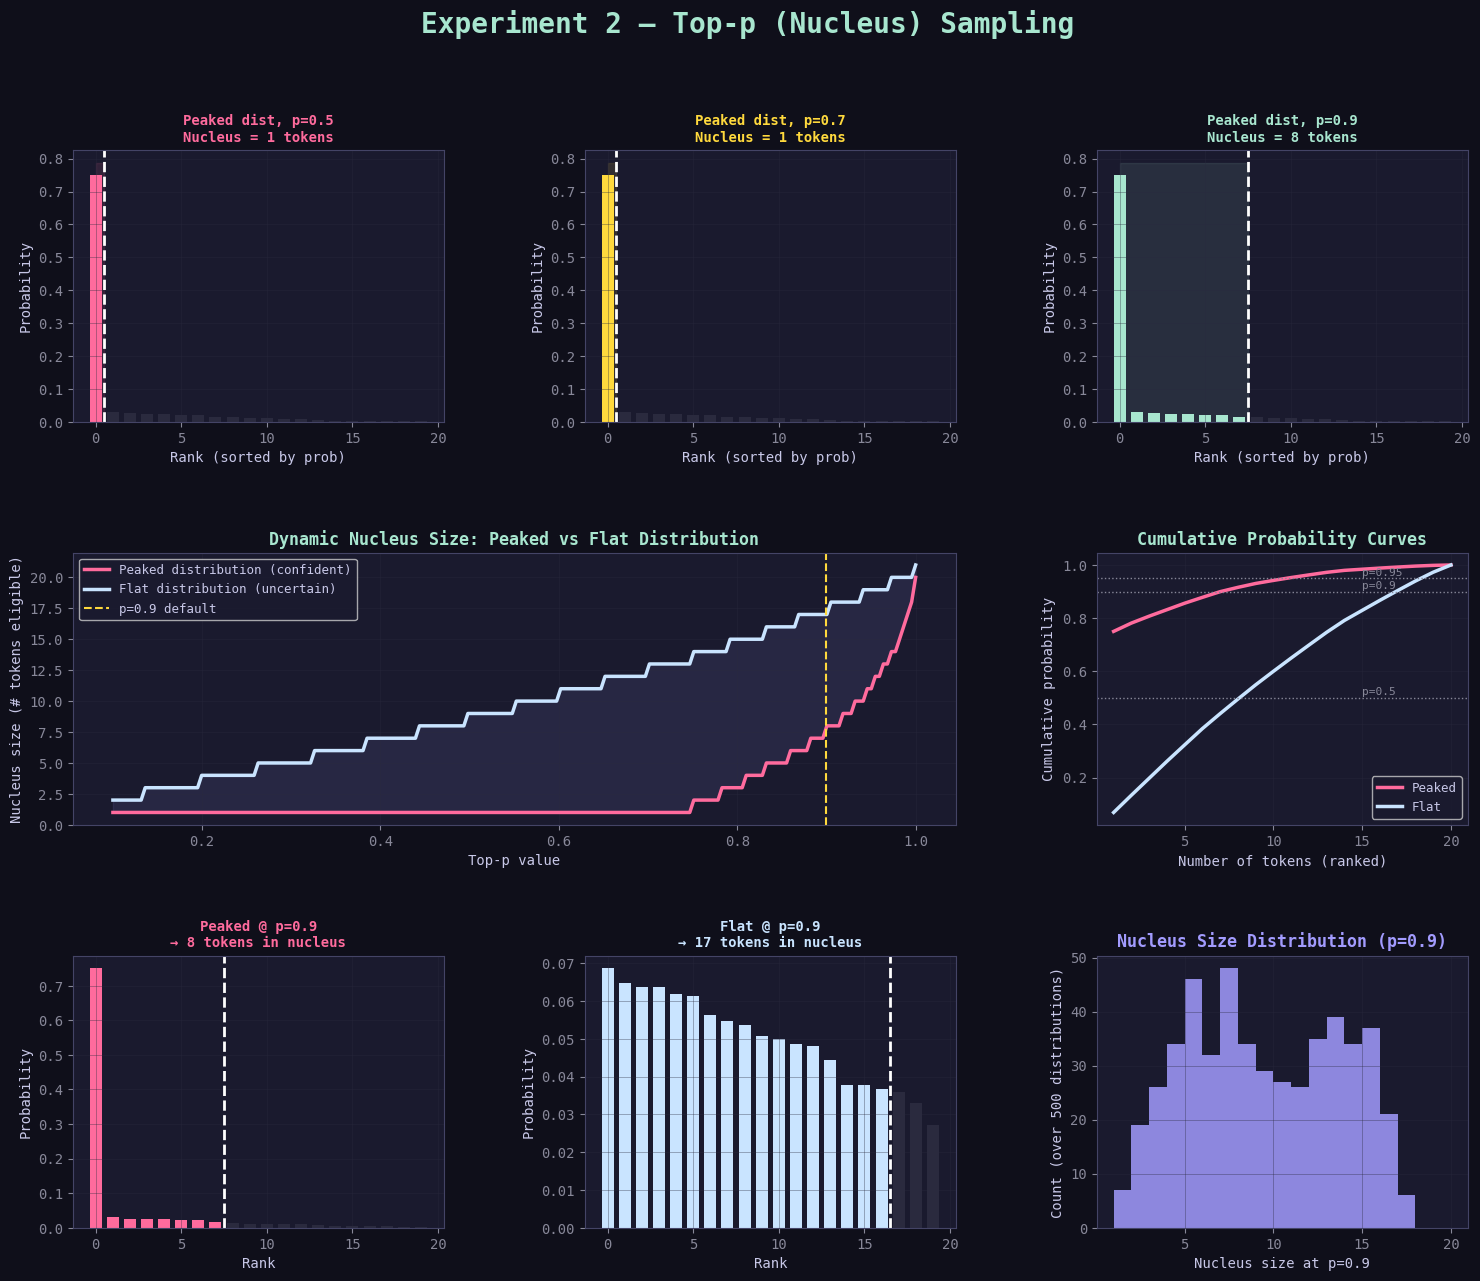

💾 Saved exp2_top_p.png


In [6]:
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.38)
fig.suptitle('Experiment 2 — Top-p (Nucleus) Sampling', fontsize=20, 
             fontweight='bold', color='#a8e6cf', y=0.98)

p_values = [0.5, 0.7, 0.9, 0.95, 1.0]
colors_p = ['#ff6b9d', '#ffd93d', '#a8e6cf', '#c9e4ff', '#a29bfe']

logits_peaked = make_logits(n=20, style='peaked')
logits_flat   = make_logits(n=20, style='flat')

probs_peaked = softmax(logits_peaked)
probs_flat   = softmax(logits_flat)

# ─── Row 0: Visualize nucleus for peaked distribution ─────────────────────────
for j, (p, col) in enumerate(zip(p_values[:3], colors_p[:3])):
    ax = fig.add_subplot(gs[0, j])
    filtered, n_tokens = apply_top_p(probs_peaked, p)
    sorted_idx = np.argsort(probs_peaked)[::-1]
    sorted_probs = probs_peaked[sorted_idx]
    
    bar_colors = [col if i < n_tokens else '#2a2a3e' for i in range(len(sorted_probs))]
    ax.bar(range(len(sorted_probs)), sorted_probs, color=bar_colors, width=0.7, edgecolor='none')
    ax.axvline(n_tokens - 0.5, color='white', lw=2, ls='--')
    ax.fill_betweenx([0, sorted_probs.max() * 1.05], 0, n_tokens - 0.5, 
                     alpha=0.1, color=col)
    ax.set_title(f'Peaked dist, p={p}\nNucleus = {n_tokens} tokens', 
                 color=col, fontsize=10, fontweight='bold')
    ax.set_xlabel('Rank (sorted by prob)')
    ax.set_ylabel('Probability')

# ─── Panel: Dynamic nucleus comparison (peaked vs flat) ───────────────────────
ax_dyn = fig.add_subplot(gs[1, :2])
p_range = np.linspace(0.1, 1.0, 200)

sizes_peaked = [apply_top_p(probs_peaked, p)[1] for p in p_range]
sizes_flat   = [apply_top_p(probs_flat,   p)[1] for p in p_range]

ax_dyn.plot(p_range, sizes_peaked, color='#ff6b9d', lw=2.5, label='Peaked distribution (confident)')
ax_dyn.plot(p_range, sizes_flat,   color='#c9e4ff', lw=2.5, label='Flat distribution (uncertain)')
ax_dyn.fill_between(p_range, sizes_peaked, sizes_flat, alpha=0.1, color='#a29bfe')
ax_dyn.axvline(0.9, color='#ffd93d', lw=1.5, ls='--', label='p=0.9 default')
ax_dyn.set_xlabel('Top-p value')
ax_dyn.set_ylabel('Nucleus size (# tokens eligible)')
ax_dyn.set_title('Dynamic Nucleus Size: Peaked vs Flat Distribution', 
                 color='#a8e6cf', fontweight='bold')
ax_dyn.legend(fontsize=9)

# ─── Panel: Cumulative probability curve ─────────────────────────────────────
ax_cum = fig.add_subplot(gs[1, 2])
for probs_ex, lbl, col in [(probs_peaked, 'Peaked', '#ff6b9d'), 
                             (probs_flat, 'Flat', '#c9e4ff')]:
    sorted_p = np.sort(probs_ex)[::-1]
    cumsum = np.cumsum(sorted_p)
    ax_cum.plot(range(1, len(cumsum)+1), cumsum, color=col, lw=2.5, label=lbl)
for p_line in [0.5, 0.9, 0.95]:
    ax_cum.axhline(p_line, color='#888899', lw=1, ls=':')
    ax_cum.text(15, p_line + 0.01, f'p={p_line}', color='#888899', fontsize=8)
ax_cum.set_xlabel('Number of tokens (ranked)')
ax_cum.set_ylabel('Cumulative probability')
ax_cum.set_title('Cumulative Probability Curves', color='#a8e6cf', fontweight='bold')
ax_cum.legend(fontsize=9)

# ─── Row 2: Show how same p=0.9 behaves differently on peaked vs flat ─────────
for j, (probs_ex, lbl, col) in enumerate([
        (probs_peaked, 'Peaked @ p=0.9', '#ff6b9d'),
        (probs_flat,   'Flat @ p=0.9',   '#c9e4ff')]):
    ax = fig.add_subplot(gs[2, j])
    filtered, n_tok = apply_top_p(probs_ex, 0.9)
    sorted_idx = np.argsort(probs_ex)[::-1]
    sorted_p   = probs_ex[sorted_idx]
    barcols = [col if i < n_tok else '#2a2a3e' for i in range(len(sorted_p))]
    ax.bar(range(len(sorted_p)), sorted_p, color=barcols, width=0.7)
    ax.axvline(n_tok - 0.5, color='white', lw=2, ls='--')
    ax.set_title(f'{lbl}\n→ {n_tok} tokens in nucleus', color=col, fontsize=10, fontweight='bold')
    ax.set_xlabel('Rank')
    ax.set_ylabel('Probability')

# ─── Panel: p=0.9 nucleus size across 100 random distributions ───────────────
ax_hist = fig.add_subplot(gs[2, 2])
rng = np.random.default_rng(0)
nucleus_sizes = []
for _ in range(500):
    l = rng.normal(0, rng.uniform(0.5, 3), 20)
    p2 = softmax(l)
    _, sz = apply_top_p(p2, 0.9)
    nucleus_sizes.append(sz)
ax_hist.hist(nucleus_sizes, bins=range(1, 21), color='#a29bfe', edgecolor='none', alpha=0.85)
ax_hist.set_xlabel('Nucleus size at p=0.9')
ax_hist.set_ylabel('Count (over 500 distributions)')
ax_hist.set_title('Nucleus Size Distribution (p=0.9)', color='#a29bfe', fontweight='bold')

plt.savefig('exp2_top_p.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('💾 Saved exp2_top_p.png')

### 🎯 Experiment 2 Takeaway

> **Top-p is adaptive.** The same `p=0.9` keeps only 2 tokens when the model is confident, but keeps 15 tokens when it's uncertain. This is its superpower over top-k.

---
# Experiment 3: Top-k Sampling 📊

**Question**: How does top-k differ from top-p, and when does it fall short?

**Key difference**: Top-k is a *fixed-size* window; top-p is *probability-adaptive*.

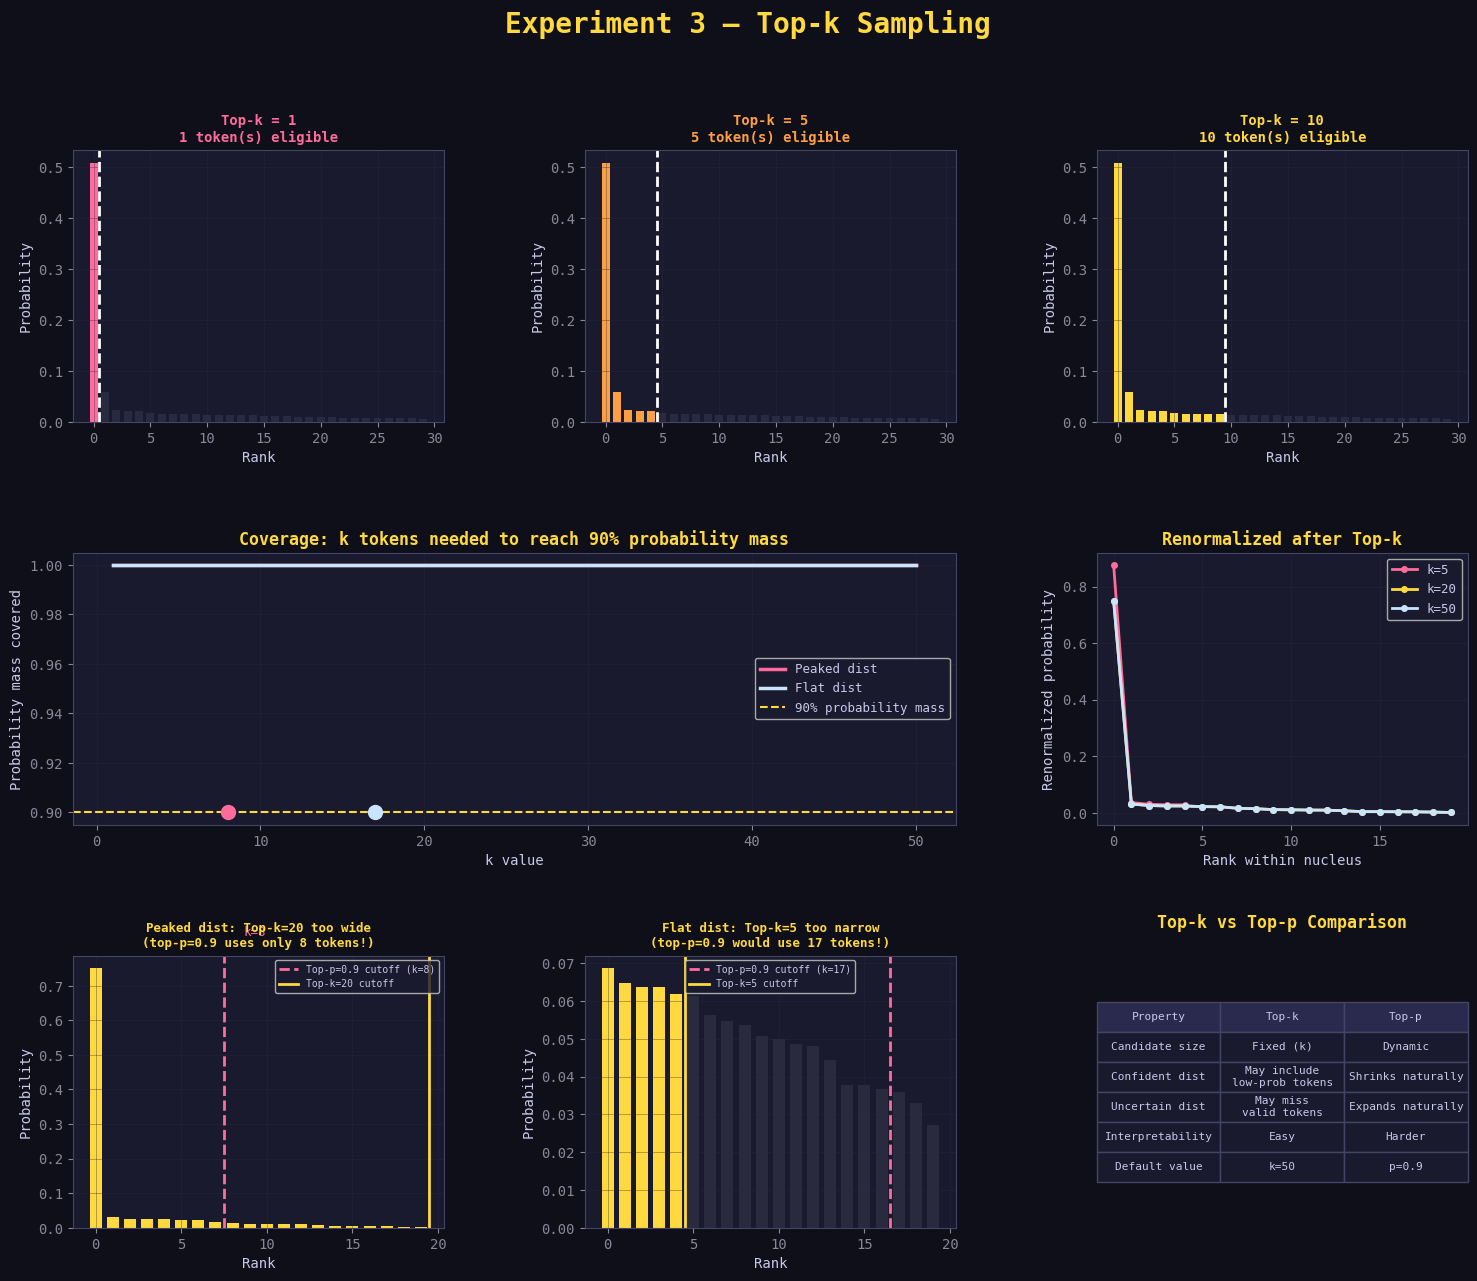

💾 Saved exp3_top_k.png


In [7]:
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.38)
fig.suptitle('Experiment 3 — Top-k Sampling', fontsize=20, 
             fontweight='bold', color='#ffd93d', y=0.98)

k_values = [1, 5, 10, 30, 50]
k_colors = ['#ff6b9d', '#ff9f43', '#ffd93d', '#a8e6cf', '#c9e4ff']

logits_ex = make_logits(n=50, style='peaked')
probs_ex  = softmax(logits_ex)

# ─── Row 0: Top-k distributions ──────────────────────────────────────────────
for j, (k, col) in enumerate(zip([1, 5, 10], k_colors[:3])):
    ax = fig.add_subplot(gs[0, j])
    filtered = apply_top_k(probs_ex, k)
    sorted_idx = np.argsort(probs_ex)[::-1]
    
    bar_colors = [col if i < k else '#2a2a3e' for i in range(30)]
    ax.bar(range(30), probs_ex[sorted_idx[:30]], color=bar_colors, width=0.7)
    ax.axvline(k - 0.5, color='white', lw=2, ls='--')
    ax.set_title(f'Top-k = {k}\n{k} token(s) eligible', color=col, fontweight='bold', fontsize=10)
    ax.set_xlabel('Rank')
    ax.set_ylabel('Probability')

# ─── Panel: Top-k vs Top-p coverage comparison ────────────────────────────────
ax_cmp = fig.add_subplot(gs[1, :2])
k_range = range(1, 51)

# Probability mass covered by top-k
coverage_peaked = [apply_top_k(probs_peaked, k).sum() for k in k_range]
coverage_flat   = [apply_top_k(probs_flat,   k).sum() for k in k_range]

ax_cmp.plot(k_range, coverage_peaked, color='#ff6b9d', lw=2.5, label='Peaked dist')
ax_cmp.plot(k_range, coverage_flat,   color='#c9e4ff', lw=2.5, label='Flat dist')
ax_cmp.axhline(0.9, color='#ffd93d', lw=1.5, ls='--', label='90% probability mass')

# Find k that achieves 90% for each
sorted_peaked = np.sort(probs_peaked)[::-1]
sorted_flat   = np.sort(probs_flat)[::-1]
k_90_peaked = np.searchsorted(np.cumsum(sorted_peaked), 0.9) + 1
k_90_flat   = np.searchsorted(np.cumsum(sorted_flat),   0.9) + 1
ax_cmp.scatter([k_90_peaked], [0.9], color='#ff6b9d', s=100, zorder=5)
ax_cmp.scatter([k_90_flat],   [0.9], color='#c9e4ff', s=100, zorder=5)
ax_cmp.annotate(f'k={k_90_peaked}', (k_90_peaked, 0.9), 
                xytext=(k_90_peaked+1, 0.85), color='#ff6b9d', fontsize=9)
ax_cmp.annotate(f'k={k_90_flat}',   (k_90_flat,   0.9), 
                xytext=(k_90_flat+1,  0.83), color='#c9e4ff', fontsize=9)
ax_cmp.set_xlabel('k value')
ax_cmp.set_ylabel('Probability mass covered')
ax_cmp.set_title('Coverage: k tokens needed to reach 90% probability mass', 
                 color='#ffd93d', fontweight='bold')
ax_cmp.legend(fontsize=9)

# ─── Panel: Renormalized distribution after top-k ─────────────────────────────
ax_renorm = fig.add_subplot(gs[1, 2])
for k, col in zip([5, 20, 50], ['#ff6b9d', '#ffd93d', '#c9e4ff']):
    filt = apply_top_k(probs_peaked, k)
    sorted_f = np.sort(filt[filt > 0])[::-1]
    ax_renorm.plot(range(len(sorted_f)), sorted_f, color=col, lw=2, 
                  marker='o', ms=4, label=f'k={k}')
ax_renorm.set_xlabel('Rank within nucleus')
ax_renorm.set_ylabel('Renormalized probability')
ax_renorm.set_title('Renormalized after Top-k', color='#ffd93d', fontweight='bold')
ax_renorm.legend(fontsize=9)

# ─── Row 2: Top-k vs Top-p failure modes ─────────────────────────────────────
# Left: Top-k too wide on peaked distribution
ax_fail1 = fig.add_subplot(gs[2, 0])
sorted_idx = np.argsort(probs_peaked)[::-1]
k_fixed = 20
_, p_nucleus = apply_top_p(probs_peaked, 0.9)
bar_colors = ['#ffd93d' if i < k_fixed else '#2a2a3e' for i in range(20)]
ax_fail1.bar(range(20), probs_peaked[sorted_idx[:20]], color=bar_colors, width=0.7)
ax_fail1.axvline(p_nucleus - 0.5, color='#ff6b9d', lw=2, ls='--', label=f'Top-p=0.9 cutoff (k={p_nucleus})')
ax_fail1.axvline(k_fixed - 0.5, color='#ffd93d', lw=2, ls='-', label=f'Top-k={k_fixed} cutoff')
ax_fail1.set_title(f'Peaked dist: Top-k={k_fixed} too wide\n(top-p=0.9 uses only {p_nucleus} tokens!)',
                  color='#ffd93d', fontsize=9, fontweight='bold')
ax_fail1.legend(fontsize=7)
ax_fail1.set_xlabel('Rank')
ax_fail1.set_ylabel('Probability')

# Middle: Top-k too narrow on flat distribution
ax_fail2 = fig.add_subplot(gs[2, 1])
sorted_idx_f = np.argsort(probs_flat)[::-1]
_, p_nucleus_f = apply_top_p(probs_flat, 0.9)
k_narrow = 5
bar_colors2 = ['#ffd93d' if i < k_narrow else '#2a2a3e' for i in range(20)]
ax_fail2.bar(range(20), probs_flat[sorted_idx_f[:20]], color=bar_colors2, width=0.7)
ax_fail2.axvline(p_nucleus_f - 0.5, color='#ff6b9d', lw=2, ls='--', label=f'Top-p=0.9 cutoff (k={p_nucleus_f})')
ax_fail2.axvline(k_narrow - 0.5, color='#ffd93d', lw=2, ls='-', label=f'Top-k={k_narrow} cutoff')
ax_fail2.set_title(f'Flat dist: Top-k={k_narrow} too narrow\n(top-p=0.9 would use {p_nucleus_f} tokens!)',
                  color='#ffd93d', fontsize=9, fontweight='bold')
ax_fail2.legend(fontsize=7)
ax_fail2.set_xlabel('Rank')
ax_fail2.set_ylabel('Probability')

# Right: Summary table visualization
ax_sum = fig.add_subplot(gs[2, 2])
ax_sum.axis('off')
table_data = [
    ['Property', 'Top-k', 'Top-p'],
    ['Candidate size', 'Fixed (k)', 'Dynamic'],
    ['Confident dist', 'May include\nlow-prob tokens', 'Shrinks naturally'],
    ['Uncertain dist', 'May miss\nvalid tokens', 'Expands naturally'],
    ['Interpretability', 'Easy', 'Harder'],
    ['Default value', 'k=50', 'p=0.9'],
]
tbl = ax_sum.table(cellText=table_data[1:], colLabels=table_data[0],
                   loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.8)
for (r, c), cell in tbl.get_celld().items():
    cell.set_facecolor('#1a1a2e' if r > 0 else '#2a2a4e')
    cell.set_edgecolor('#444466')
    cell.set_text_props(color='#c8c8e8')
ax_sum.set_title('Top-k vs Top-p Comparison', color='#ffd93d', fontweight='bold', pad=20)

plt.savefig('exp3_top_k.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('💾 Saved exp3_top_k.png')

### 🎯 Experiment 3 Takeaway

> **Top-k doesn't adapt.** When the model is confident, k=50 may still include many near-zero tokens. When the model is uncertain, k=5 may cut off valid options. Top-p is generally preferred, but combining both gives you the best of both worlds.

---
# Experiment 4: Combined Filters 🔀

**Question**: What happens when you mix temperature + top-p + top-k?

**Key insight**: Order matters. Temperature reshapes the logits *first*, then top-k/top-p operate on the reshaped distribution.

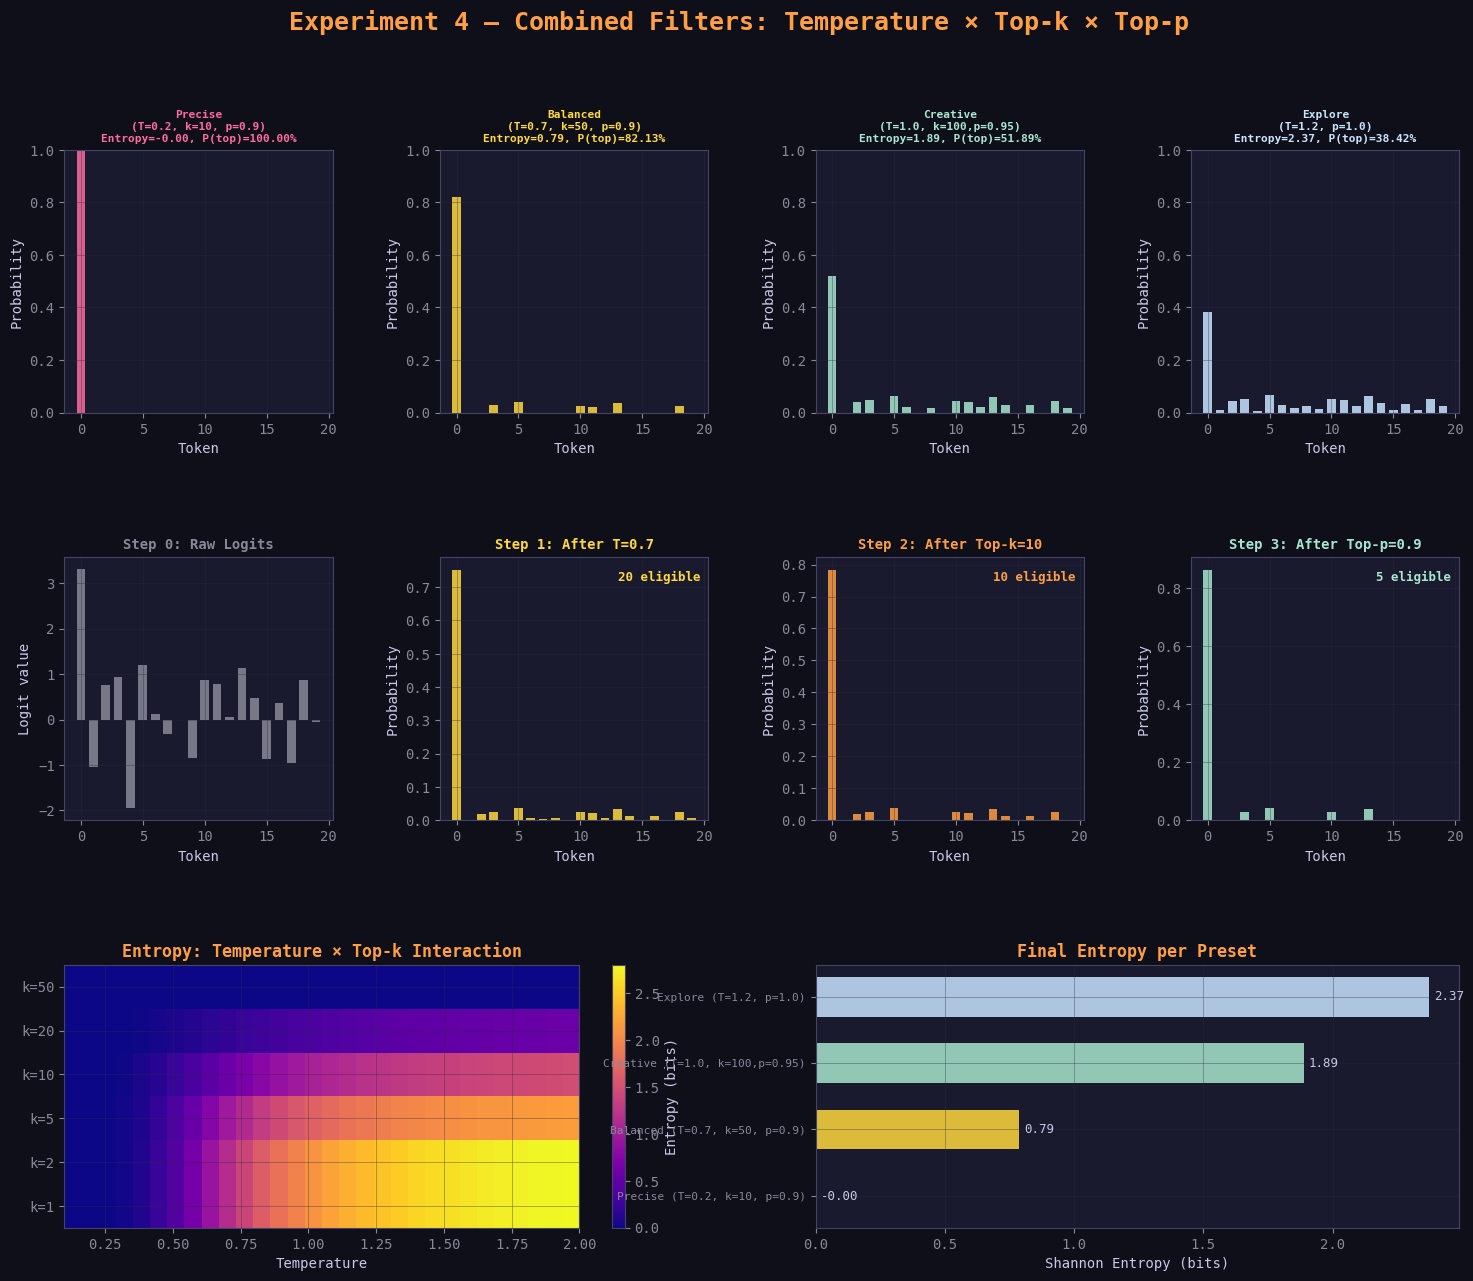

💾 Saved exp4_combined.png


In [8]:
logits_base = make_logits(n=20, style='bimodal')

presets = [
    {'name': 'Precise\n(T=0.2, k=10, p=0.9)', 'T': 0.2, 'k': 10,  'p': 0.9,  'color': '#ff6b9d'},
    {'name': 'Balanced\n(T=0.7, k=50, p=0.9)', 'T': 0.7, 'k': 50,  'p': 0.9,  'color': '#ffd93d'},
    {'name': 'Creative\n(T=1.0, k=100,p=0.95)','T': 1.0, 'k': 100, 'p': 0.95, 'color': '#a8e6cf'},
    {'name': 'Explore\n(T=1.2, p=1.0)',         'T': 1.2, 'k': 0,   'p': 1.0,  'color': '#c9e4ff'},
]

fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.4)
fig.suptitle('Experiment 4 — Combined Filters: Temperature × Top-k × Top-p', 
             fontsize=18, fontweight='bold', color='#ff9f43', y=0.98)

# ─── Row 0: Final distributions for each preset ───────────────────────────────
for j, preset in enumerate(presets):
    ax = fig.add_subplot(gs[0, j])
    T, k, p, col = preset['T'], preset['k'], preset['p'], preset['color']
    
    # Apply pipeline: temperature → top-k → top-p
    scaled = apply_temperature(logits_base, T)
    probs  = softmax(scaled)
    if k > 0:
        probs = apply_top_k(probs, k)
    probs, nucleus_sz = apply_top_p(probs, p)
    
    ax.bar(range(len(probs)), probs, color=col, alpha=0.85, width=0.7)
    entropy = -np.sum(probs * np.log(probs + 1e-12))
    top_p_val = probs.max()
    ax.set_title(f"{preset['name']}\nEntropy={entropy:.2f}, P(top)={top_p_val:.2%}",
                color=col, fontsize=8, fontweight='bold')
    ax.set_xlabel('Token')
    ax.set_ylabel('Probability')
    ax.set_ylim(0, 1.0)

# ─── Row 1: Pipeline visualization step-by-step for Balanced preset ───────────
T_show = 0.7
steps = [
    ('Raw Logits', logits_base, '#888899'),
    (f'After T={T_show}', softmax(apply_temperature(logits_base, T_show)), '#ffd93d'),
    ('After Top-k=10', apply_top_k(softmax(apply_temperature(logits_base, T_show)), 10), '#ff9f43'),
    ('After Top-p=0.9', apply_top_p(apply_top_k(softmax(apply_temperature(logits_base, T_show)), 10), 0.9)[0], '#a8e6cf'),
]

for j, (lbl, data, col) in enumerate(steps):
    ax = fig.add_subplot(gs[1, j])
    if j == 0:
        ax.bar(range(len(data)), data, color=col, alpha=0.85, width=0.7)
        ax.set_ylabel('Logit value')
    else:
        ax.bar(range(len(data)), data, color=col, alpha=0.85, width=0.7)
        ax.set_ylabel('Probability')
    ax.set_title(f'Step {j}: {lbl}', color=col, fontweight='bold', fontsize=10)
    ax.set_xlabel('Token')
    if j > 0:
        eligible = np.sum(data > 0)
        ax.text(0.97, 0.95, f'{eligible} eligible', transform=ax.transAxes,
               ha='right', va='top', color=col, fontsize=9, fontweight='bold')

# ─── Row 2: Interaction heatmap: Entropy across T × Top-k ─────────────────────
ax_heat = fig.add_subplot(gs[2, :2])
T_vals = np.linspace(0.1, 2.0, 30)
k_vals = [1, 2, 5, 10, 20, 50]
entropy_grid = np.zeros((len(k_vals), len(T_vals)))
for i, kv in enumerate(k_vals):
    for j2, tv in enumerate(T_vals):
        pr = softmax(apply_temperature(logits_base, tv))
        pr = apply_top_k(pr, kv)
        entropy_grid[i, j2] = -np.sum(pr * np.log(pr + 1e-12))

im = ax_heat.imshow(entropy_grid, aspect='auto', cmap='plasma',
                    extent=[T_vals[0], T_vals[-1], 0, len(k_vals)])
plt.colorbar(im, ax=ax_heat, label='Entropy (bits)')
ax_heat.set_yticks(np.arange(len(k_vals)) + 0.5)
ax_heat.set_yticklabels([f'k={kv}' for kv in k_vals])
ax_heat.set_xlabel('Temperature')
ax_heat.set_title('Entropy: Temperature × Top-k Interaction', 
                 color='#ff9f43', fontweight='bold')

# ─── Row 2 right: Entropy comparison across presets ──────────────────────────
ax_ent_bar = fig.add_subplot(gs[2, 2:])
preset_entropies = []
preset_names = []
for pr in presets:
    sc = apply_temperature(logits_base, pr['T'])
    p2 = softmax(sc)
    if pr['k'] > 0:
        p2 = apply_top_k(p2, pr['k'])
    p2, _ = apply_top_p(p2, pr['p'])
    e = -np.sum(p2 * np.log(p2 + 1e-12))
    preset_entropies.append(e)
    preset_names.append(pr['name'].replace('\n', ' '))

bars = ax_ent_bar.barh(range(len(presets)), preset_entropies,
                       color=[p['color'] for p in presets], alpha=0.85, height=0.6)
ax_ent_bar.set_yticks(range(len(presets)))
ax_ent_bar.set_yticklabels(preset_names, fontsize=8)
for i, (bar, val) in enumerate(zip(bars, preset_entropies)):
    ax_ent_bar.text(val + 0.02, i, f'{val:.2f}', va='center', fontsize=9)
ax_ent_bar.set_xlabel('Shannon Entropy (bits)')
ax_ent_bar.set_title('Final Entropy per Preset', color='#ff9f43', fontweight='bold')

plt.savefig('exp4_combined.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('💾 Saved exp4_combined.png')

### 🎯 Experiment 4 Takeaway

> **Combining parameters has multiplicative effects.** High temperature + low top-p can produce results similar to low temperature + high top-p, but they are NOT the same — they select different token identities. Always adjust one parameter at a time and measure entropy to understand where you are.

---
# Experiment 5: Repetition Penalties 🔁

**Question**: How do repetition penalties discourage the model from repeating tokens?

**Key insight**: Penalties are applied *before* sampling by modifying the logits of already-seen tokens.

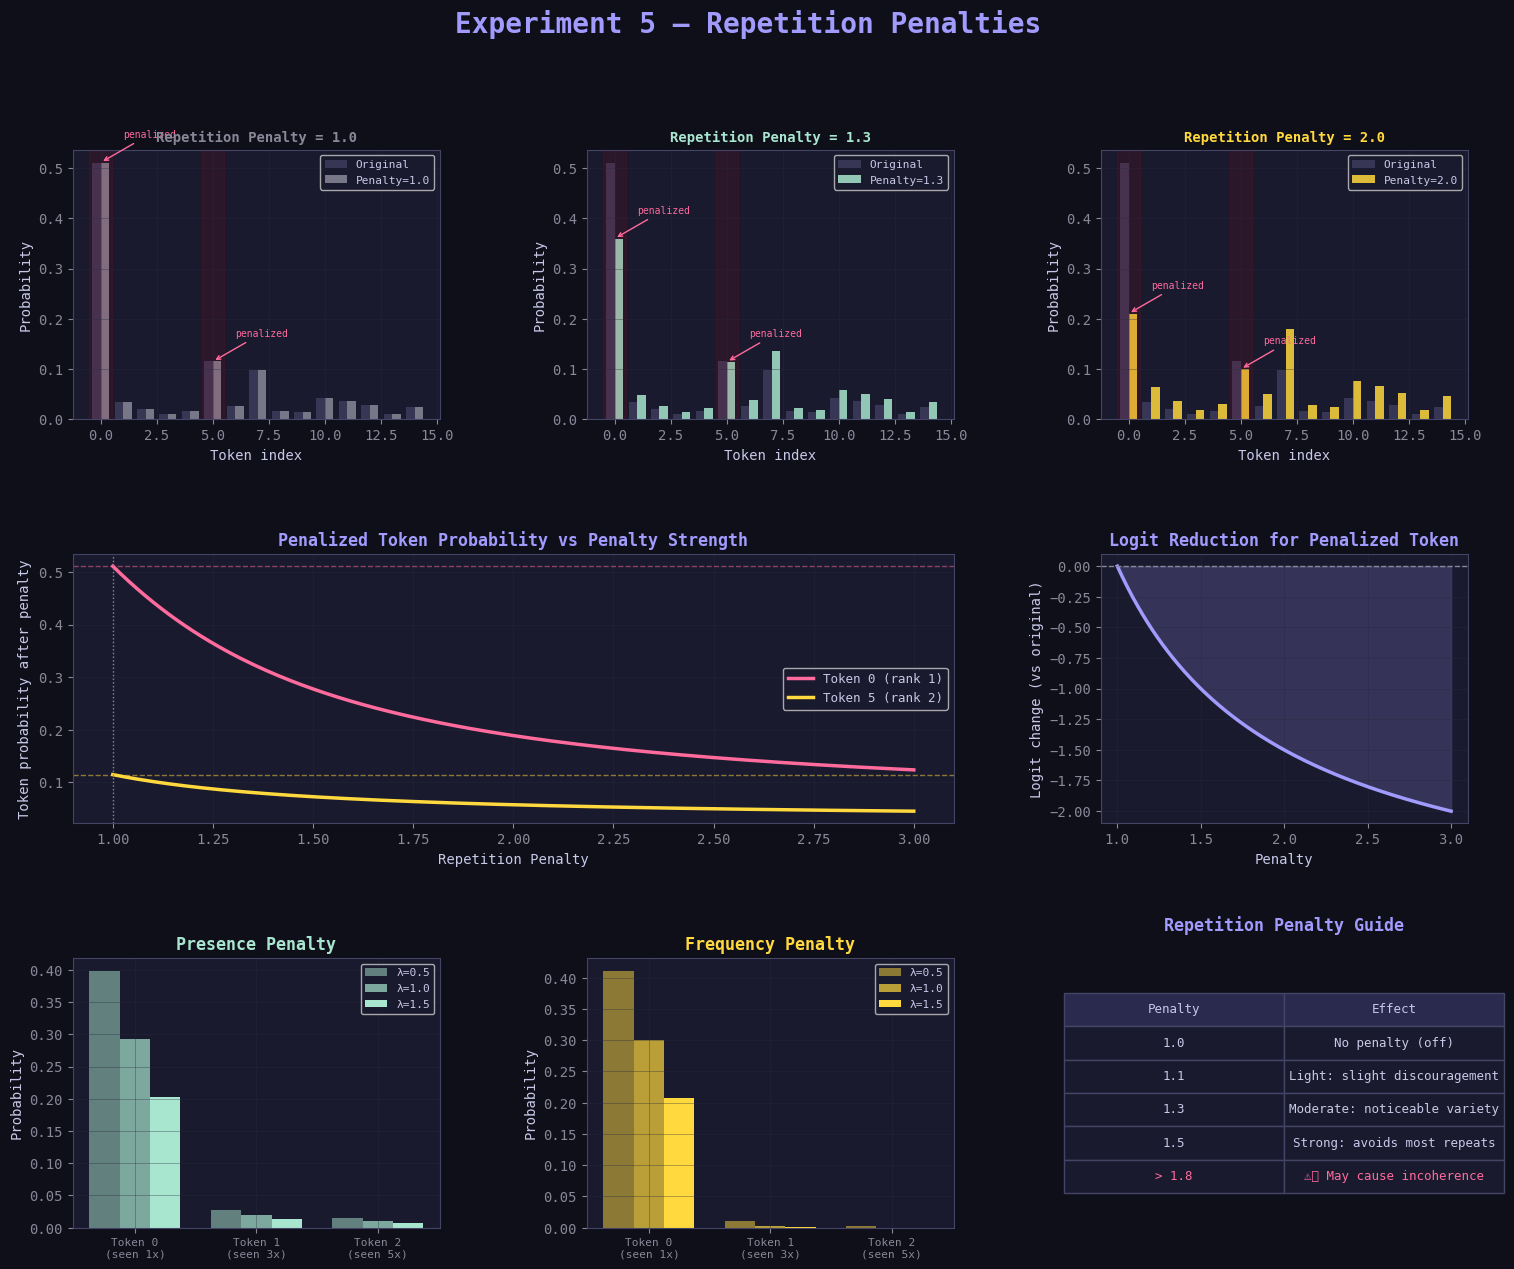

💾 Saved exp5_repetition.png


In [9]:
logits_rep = make_logits(n=15, seed=7, style='bimodal')
# Token 0 is dominant; pretend token 0 and token 5 were already generated
generated = [0, 5]
penalties = [1.0, 1.1, 1.3, 1.5, 2.0]
pen_colors = ['#888899', '#a8e6cf', '#ffd93d', '#ff9f43', '#ff6b9d']

fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.4)
fig.suptitle('Experiment 5 — Repetition Penalties', fontsize=20,
             fontweight='bold', color='#a29bfe', y=0.98)

# ─── Row 0: Distribution before/after penalty for 3 strengths ────────────────
for j, (pen, col) in enumerate(zip([1.0, 1.3, 2.0], pen_colors[0:3])):
    ax = fig.add_subplot(gs[0, j])
    penalized = apply_repetition_penalty(logits_rep, pen, generated)
    probs_orig = softmax(logits_rep)
    probs_pen  = softmax(penalized)
    
    x = np.arange(len(probs_orig))
    w = 0.38
    bars_o = ax.bar(x - w/2, probs_orig, width=w, color='#444466', alpha=0.7, label='Original')
    bars_p = ax.bar(x + w/2, probs_pen,  width=w, color=col,      alpha=0.85, label=f'Penalty={pen}')
    
    # Highlight penalized tokens
    for tok in generated:
        ax.axvspan(tok - 0.5, tok + 0.5, color='red', alpha=0.08)
        ax.annotate('penalized', xy=(tok, probs_pen[tok]), 
                   xytext=(tok + 1, probs_pen[tok] + 0.05),
                   fontsize=7, color='#ff6b9d',
                   arrowprops=dict(arrowstyle='->', color='#ff6b9d', lw=1))
    
    ax.set_title(f'Repetition Penalty = {pen}', color=col, fontweight='bold', fontsize=10)
    ax.set_xlabel('Token index')
    ax.set_ylabel('Probability')
    ax.legend(fontsize=8)

# ─── Panel: Probability of penalized tokens vs penalty strength ───────────────
ax_pen = fig.add_subplot(gs[1, :2])
pen_range = np.linspace(1.0, 3.0, 200)
for tok_idx, col in zip(generated, ['#ff6b9d', '#ffd93d']):
    tok_probs = []
    for pen in pen_range:
        penalized_l = apply_repetition_penalty(logits_rep, pen, [tok_idx])
        p_pen = softmax(penalized_l)
        tok_probs.append(p_pen[tok_idx])
    ax_pen.plot(pen_range, tok_probs, color=col, lw=2.5, label=f'Token {tok_idx} (rank {np.argsort(softmax(logits_rep))[::-1].tolist().index(tok_idx)+1})')

original_probs = softmax(logits_rep)
for tok_idx, col in zip(generated, ['#ff6b9d', '#ffd93d']):
    ax_pen.axhline(original_probs[tok_idx], color=col, lw=1, ls='--', alpha=0.5)

ax_pen.axvline(1.0, color='#888899', lw=1, ls=':')
ax_pen.set_xlabel('Repetition Penalty')
ax_pen.set_ylabel('Token probability after penalty')
ax_pen.set_title('Penalized Token Probability vs Penalty Strength', 
                color='#a29bfe', fontweight='bold')
ax_pen.legend(fontsize=9)

# ─── Panel: Logit shift visualization ────────────────────────────────────────
ax_logit = fig.add_subplot(gs[1, 2])
logit_shifts = []
for pen in pen_range:
    penalized_l = apply_repetition_penalty(logits_rep, pen, [0])
    shift = penalized_l[0] - logits_rep[0]
    logit_shifts.append(shift)

ax_logit.plot(pen_range, logit_shifts, color='#a29bfe', lw=2.5)
ax_logit.fill_between(pen_range, logit_shifts, alpha=0.2, color='#a29bfe')
ax_logit.axhline(0, color='#888899', lw=1, ls='--')
ax_logit.set_xlabel('Penalty')
ax_logit.set_ylabel('Logit change (vs original)')
ax_logit.set_title('Logit Reduction for Penalized Token', 
                  color='#a29bfe', fontweight='bold')

# ─── Row 2: Presence vs Frequency penalty comparison ─────────────────────────
# Simulate: token 0 has appeared 1x, token 1 has appeared 3x, token 2 has appeared 5x
counts = {0: 1, 1: 3, 2: 5}  # token: count

def presence_penalty(logits, penalty_val, seen_tokens):
    l = logits.copy()
    for t in seen_tokens:
        l[t] -= penalty_val  # flat deduction
    return l

def frequency_penalty(logits, penalty_val, token_counts):
    l = logits.copy()
    for t, cnt in token_counts.items():
        l[t] -= penalty_val * cnt  # proportional to count
    return l

ax_pres = fig.add_subplot(gs[2, 0])
ax_freq = fig.add_subplot(gs[2, 1])

penalty_strengths = [0.5, 1.0, 1.5]
x3 = np.arange(3)
orig_p = softmax(logits_rep[:3] + [0])[0:3]  # just first 3 tokens
orig_l = logits_rep.copy()

for ax_t, fn, title, col in [
    (ax_pres, presence_penalty, 'Presence Penalty', '#a8e6cf'),
    (ax_freq, frequency_penalty, 'Frequency Penalty', '#ffd93d'),
]:
    width = 0.25
    for i, (strength, shade) in enumerate(zip(penalty_strengths, [0.5, 0.7, 1.0])):
        if fn == presence_penalty:
            penl = fn(orig_l, strength, list(counts.keys()))
        else:
            penl = fn(orig_l, strength, counts)
        p = softmax(penl)[:3]
        ax_t.bar(x3 + i * width, p, width=width, color=col, alpha=shade, label=f'λ={strength}')
    ax_t.set_xticks(x3 + width)
    ax_t.set_xticklabels([f'Token {i}\n(seen {counts[i]}x)' for i in range(3)], fontsize=8)
    ax_t.set_ylabel('Probability')
    ax_t.set_title(title, color=col, fontweight='bold')
    ax_t.legend(fontsize=8)

# ─── Panel: Guide table ───────────────────────────────────────────────────────
ax_guide = fig.add_subplot(gs[2, 2])
ax_guide.axis('off')
guide_data = [
    ['Penalty', 'Effect'],
    ['1.0', 'No penalty (off)'],
    ['1.1', 'Light: slight discouragement'],
    ['1.3', 'Moderate: noticeable variety'],
    ['1.5', 'Strong: avoids most repeats'],
    ['> 1.8', '⚠️ May cause incoherence'],
]
tbl = ax_guide.table(cellText=guide_data[1:], colLabels=guide_data[0],
                    loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 2.0)
for (r, c), cell in tbl.get_celld().items():
    cell.set_facecolor('#1a1a2e' if r > 0 else '#2a2a4e')
    cell.set_edgecolor('#444466')
    cell.set_text_props(color='#ff6b9d' if r == 5 else '#c8c8e8')
ax_guide.set_title('Repetition Penalty Guide', color='#a29bfe', fontweight='bold', pad=20)

plt.savefig('exp5_repetition.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('💾 Saved exp5_repetition.png')

### 🎯 Experiment 5 Takeaway

> **Repetition penalty is a scalpel, not a sledgehammer.** Use 1.1–1.3 for light diversity improvement. Above 1.5, the model starts avoiding even necessary words like "the". Frequency penalty hits repeat offenders harder than presence penalty.

---
# Experiment 6: Real Use Cases 🎯

**Question**: How should I actually tune parameters for different tasks?

**Key insight**: Every task has a different "optimal" distribution. Match your parameters to your task's needs.

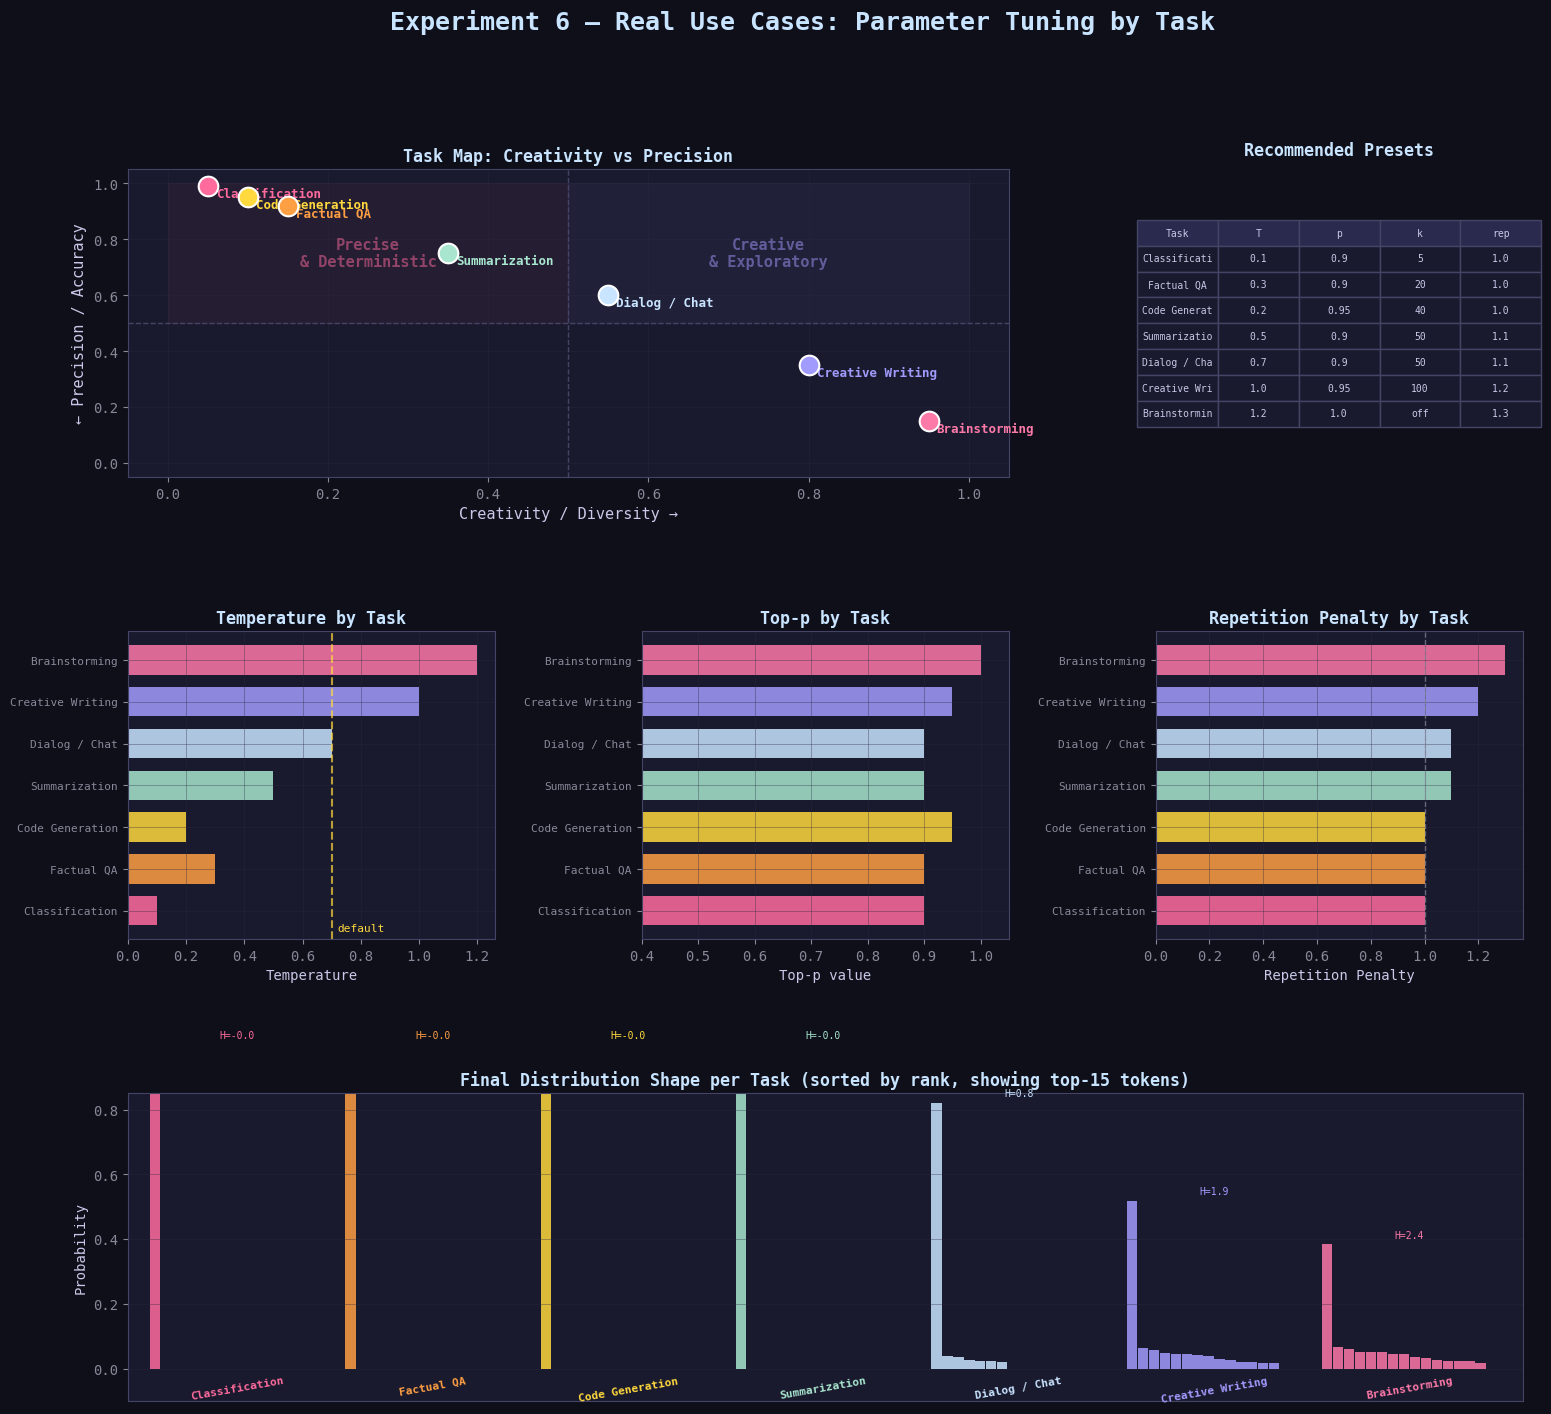

💾 Saved exp6_usecases.png


In [11]:
# Define task profiles
tasks = [
    {'name': 'Classification',      'T': 0.1,  'p': 0.9,  'k': 5,   'rep': 1.0,  'creativity': 0.05, 'precision': 0.99, 'color': '#ff6b9d'},
    {'name': 'Factual QA',           'T': 0.3,  'p': 0.9,  'k': 20,  'rep': 1.0,  'creativity': 0.15, 'precision': 0.92, 'color': '#ff9f43'},
    {'name': 'Code Generation',      'T': 0.2,  'p': 0.95, 'k': 40,  'rep': 1.0,  'creativity': 0.10, 'precision': 0.95, 'color': '#ffd93d'},
    {'name': 'Summarization',        'T': 0.5,  'p': 0.9,  'k': 50,  'rep': 1.1,  'creativity': 0.35, 'precision': 0.75, 'color': '#a8e6cf'},
    {'name': 'Dialog / Chat',        'T': 0.7,  'p': 0.9,  'k': 50,  'rep': 1.1,  'creativity': 0.55, 'precision': 0.60, 'color': '#c9e4ff'},
    {'name': 'Creative Writing',     'T': 1.0,  'p': 0.95, 'k': 100, 'rep': 1.2,  'creativity': 0.80, 'precision': 0.35, 'color': '#a29bfe'},
    {'name': 'Brainstorming',        'T': 1.2,  'p': 1.0,  'k': 0,   'rep': 1.3,  'creativity': 0.95, 'precision': 0.15, 'color': '#fd79a8'},
]

fig = plt.figure(figsize=(18, 16))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.4)
fig.suptitle('Experiment 6 — Real Use Cases: Parameter Tuning by Task', 
             fontsize=18, fontweight='bold', color='#c9e4ff', y=0.98)

# ─── Panel A: Creativity vs Precision scatter ─────────────────────────────────
ax_scatter = fig.add_subplot(gs[0, :2])
for task in tasks:
    ax_scatter.scatter(task['creativity'], task['precision'], 
                      s=200, color=task['color'], zorder=5, edgecolors='white', lw=1.5)
    ax_scatter.annotate(task['name'], 
                       xy=(task['creativity'], task['precision']),
                       xytext=(task['creativity'] + 0.01, task['precision'] - 0.04),
                       fontsize=9, color=task['color'], fontweight='bold')

# Draw quadrant zones
from matplotlib.patches import FancyBboxPatch
zones = [
    (0, 0.5, 0.5, 0.5, '#ff6b9d', 0.05, 'Precise\n& Deterministic'),
    (0.5, 0.5, 0.5, 0.5, '#a29bfe', 0.05, 'Creative\n& Exploratory'),
]
for (x0, y0, w, h, col, alpha, lbl) in zones:
    rect = Rectangle((x0, y0), w, h, color=col, alpha=alpha, zorder=0)
    ax_scatter.add_patch(rect)
    ax_scatter.text(x0 + w/2, y0 + h/2, lbl, ha='center', va='center',
                   color=col, alpha=0.5, fontsize=11, fontweight='bold')

ax_scatter.set_xlim(-0.05, 1.05)
ax_scatter.set_ylim(-0.05, 1.05)
ax_scatter.set_xlabel('Creativity / Diversity →', fontsize=11)
ax_scatter.set_ylabel('← Precision / Accuracy', fontsize=11)
ax_scatter.set_title('Task Map: Creativity vs Precision', color='#c9e4ff', fontweight='bold')
ax_scatter.axhline(0.5, color='#444466', lw=1, ls='--')
ax_scatter.axvline(0.5, color='#444466', lw=1, ls='--')

# ─── Panel B: Parameter table ─────────────────────────────────────────────────
ax_table = fig.add_subplot(gs[0, 2])
ax_table.axis('off')
table_rows = [['Task', 'T', 'p', 'k', 'rep']]
for t in tasks:
    k_str = str(t['k']) if t['k'] > 0 else 'off'
    table_rows.append([t['name'][:12], t['T'], t['p'], k_str, t['rep']])
tbl = ax_table.table(cellText=table_rows[1:], colLabels=table_rows[0],
                    loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(7)
tbl.scale(1.1, 1.55)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2a2a4e')
    else:
        cell.set_facecolor('#1a1a2e')
    cell.set_edgecolor('#444466')
    cell.set_text_props(color='#c8c8e8')
ax_table.set_title('Recommended Presets', color='#c9e4ff', fontweight='bold', pad=10)

# ─── Row 1: Temperature distribution per task ─────────────────────────────────
ax_T = fig.add_subplot(gs[1, 0])
task_names = [t['name'] for t in tasks]
T_values = [t['T'] for t in tasks]
colors_t = [t['color'] for t in tasks]
bars = ax_T.barh(range(len(tasks)), T_values, color=colors_t, alpha=0.85, height=0.7)
ax_T.set_yticks(range(len(tasks)))
ax_T.set_yticklabels([t['name'] for t in tasks], fontsize=8)
ax_T.set_xlabel('Temperature')
ax_T.set_title('Temperature by Task', color='#c9e4ff', fontweight='bold')
ax_T.axvline(0.7, color='#ffd93d', lw=1.5, ls='--', alpha=0.7)
ax_T.text(0.72, -0.5, 'default', color='#ffd93d', fontsize=8)

# ─── Row 1 middle: Top-p per task ─────────────────────────────────────────────
ax_p = fig.add_subplot(gs[1, 1])
p_values_t = [t['p'] for t in tasks]
ax_p.barh(range(len(tasks)), p_values_t, color=colors_t, alpha=0.85, height=0.7)
ax_p.set_yticks(range(len(tasks)))
ax_p.set_yticklabels([t['name'] for t in tasks], fontsize=8)
ax_p.set_xlabel('Top-p value')
ax_p.set_title('Top-p by Task', color='#c9e4ff', fontweight='bold')
ax_p.set_xlim(0.4, 1.05)

# ─── Row 1 right: Rep penalty per task ────────────────────────────────────────
ax_rep = fig.add_subplot(gs[1, 2])
rep_values = [t['rep'] for t in tasks]
ax_rep.barh(range(len(tasks)), rep_values, color=colors_t, alpha=0.85, height=0.7)
ax_rep.set_yticks(range(len(tasks)))
ax_rep.set_yticklabels([t['name'] for t in tasks], fontsize=8)
ax_rep.set_xlabel('Repetition Penalty')
ax_rep.set_title('Repetition Penalty by Task', color='#c9e4ff', fontweight='bold')
ax_rep.axvline(1.0, color='#888899', lw=1, ls='--', alpha=0.7)

# ─── Row 2: Probability distribution shapes per task ─────────────────────────
ax_shapes = fig.add_subplot(gs[2, :])
logits_task = make_logits(n=20, style='bimodal')
offsets = np.linspace(0, 1, len(tasks) + 1)[:-1]
scale = 0.12

for i, (task, offset) in enumerate(zip(tasks, offsets)):
    sc = apply_temperature(logits_task, task['T'])
    pr = softmax(sc)
    if task['k'] > 0:
        pr = apply_top_k(pr, task['k'])
    pr, _ = apply_top_p(pr, task['p'])
    
    # Plot each task's distribution as a small inline histogram
    sorted_pr = np.sort(pr)[::-1]
    x_start = offset
    for j2, p_val in enumerate(sorted_pr[:15]):
        bar_x = x_start + j2 * (scale / 15)
        ax_shapes.bar(bar_x, p_val, width=(scale / 16), 
                     color=task['color'], alpha=0.85, edgecolor='none')
    ax_shapes.text(x_start + scale / 2, -0.02, task['name'], 
                  ha='center', va='top', color=task['color'], fontsize=8, fontweight='bold',
                  rotation=10)
    # Entropy label
    ent = -np.sum(pr * np.log(pr + 1e-12))
    ax_shapes.text(x_start + scale / 2, pr.max() + 0.02, f'H={ent:.1f}',
                  ha='center', color=task['color'], fontsize=7)

ax_shapes.set_xlim(-0.02, 1.0)
ax_shapes.set_ylim(-0.1, 0.85)
ax_shapes.set_xticks([])
ax_shapes.set_ylabel('Probability')
ax_shapes.set_title('Final Distribution Shape per Task (sorted by rank, showing top-15 tokens)',
                   color='#c9e4ff', fontweight='bold')

plt.savefig('exp6_usecases.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('💾 Saved exp6_usecases.png')

### 🎯 Experiment 6 Takeaway

> **There is no universal parameter setting.** Classification needs near-deterministic outputs (T≈0.1). Creative writing needs high entropy (T≈1.0, high p). Always define your success metric *first*, then tune parameters to optimize for it.

---
# 🏁 Summary: All 6 Experiments at a Glance

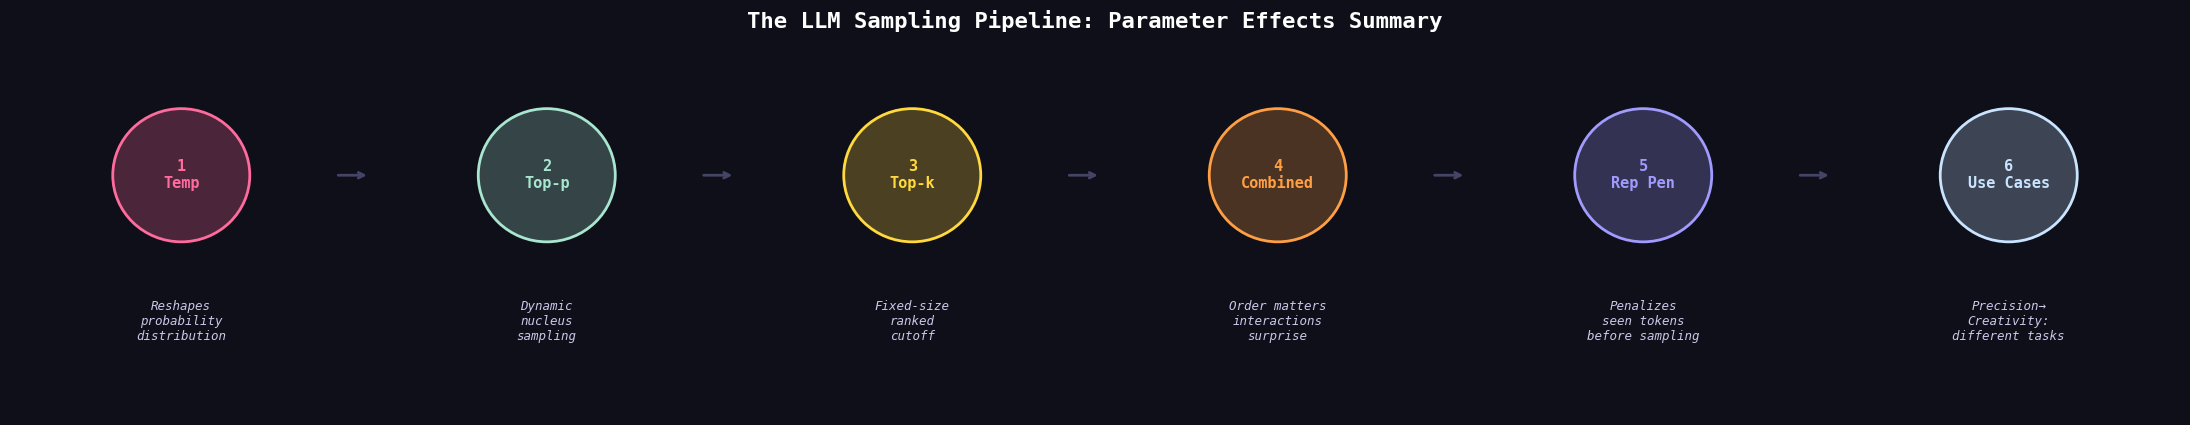

💾 Saved summary_card.png

✅ ALL 6 EXPERIMENTS COMPLETE!

Files saved:
  exp1_temperature.png
  exp2_top_p.png
  exp3_top_k.png
  exp4_combined.png
  exp5_repetition.png
  exp6_usecases.png
  summary_card.png


In [13]:
fig, axes = plt.subplots(1, 6, figsize=(22, 4))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('The LLM Sampling Pipeline: Parameter Effects Summary', 
             fontsize=16, fontweight='bold', color='white', y=1.05)

summaries = [
    ('1\nTemp', '#ff6b9d', 'Reshapes\nprobability\ndistribution'),
    ('2\nTop-p', '#a8e6cf', 'Dynamic\nnucleus\nsampling'),
    ('3\nTop-k', '#ffd93d', 'Fixed-size\nranked\ncutoff'),
    ('4\nCombined', '#ff9f43', 'Order matters\ninteractions\nsurprise'),
    ('5\nRep Pen', '#a29bfe', 'Penalizes\nseen tokens\nbefore sampling'),
    ('6\nUse Cases', '#c9e4ff', 'Precision→\nCreativity:\ndifferent tasks'),
]

for ax, (title, col, desc) in zip(axes, summaries):
    ax.set_facecolor('#1a1a2e')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    
    # Draw colored circle
    circle = plt.Circle((0.5, 0.72), 0.2, color=col, alpha=0.25)
    ax.add_patch(circle)
    circle2 = plt.Circle((0.5, 0.72), 0.2, color=col, fill=False, lw=2)
    ax.add_patch(circle2)
    ax.text(0.5, 0.72, title, ha='center', va='center', 
           color=col, fontsize=11, fontweight='bold')
    ax.text(0.5, 0.28, desc, ha='center', va='center',
           color='#c8c8e8', fontsize=9, style='italic')
    
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # Draw arrow between panels
    if ax != axes[-1]:
        ax.annotate('', xy=(1.05, 0.72), xytext=(0.95, 0.72),
                   xycoords='axes fraction', textcoords='axes fraction',
                   arrowprops=dict(arrowstyle='->', color='#444466', lw=2))

plt.tight_layout()
plt.savefig('summary_card.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('💾 Saved summary_card.png')
print()
print('='*60)
print('✅ ALL 6 EXPERIMENTS COMPLETE!')
print('='*60)
print()
print('Files saved:')
print('  exp1_temperature.png')
print('  exp2_top_p.png')
print('  exp3_top_k.png')
print('  exp4_combined.png')
print('  exp5_repetition.png')
print('  exp6_usecases.png')
print('  summary_card.png')

---
## 📋 Quick Reference Cheat Sheet

| Parameter | Range | Default | Increase → | Decrease → |
|-----------|-------|---------|------------|------------|
| **Temperature** | 0.0 – 2.0 | 0.7 | More random | More deterministic |
| **Top-p** | 0.0 – 1.0 | 0.9 | More candidates | Fewer candidates |
| **Top-k** | 1 – ∞ | 50 | More candidates | Fewer candidates |
| **Rep. penalty** | 1.0 – 2.0 | 1.0 | Avoids repeats more | No effect (1.0=off) |

### Pipeline Order
```
Raw Logits
    ↓  /temperature  (reshape)
    ↓  top-k filter  (fixed cutoff)
    ↓  top-p filter  (nucleus cutoff)
    ↓  rep. penalty  (penalize seen tokens)
    ↓  Sample!
```

### Task Presets
| Task | T | p | k | rep |
|------|---|---|---|-----|
| Classification | 0.1 | 0.9 | 5 | 1.0 |
| Code | 0.2 | 0.95 | 40 | 1.0 |
| Factual QA | 0.3 | 0.9 | 20 | 1.0 |
| Summarization | 0.5 | 0.9 | 50 | 1.1 |
| Chat | 0.7 | 0.9 | 50 | 1.1 |
| Creative | 1.0 | 0.95 | 100 | 1.2 |
| Brainstorm | 1.2 | 1.0 | off | 1.3 |